# Validation Terschelling

## Paths & Co

In [1]:
new_kalman_run = False
animation = False

In [2]:
path_to_data_folder = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/'
# path_to_data_folder = '/home/jovyan/data/98_paper2_kf_dtm/'

path_tc = path_to_data_folder + '01_tides/output/'

path_input_general = path_to_data_folder + '0_input_general/'
path_input = path_to_data_folder + '12_13_Ters_DEM/input/'
path_output = path_to_data_folder + '12_13_Ters_DEM/output/'
path_altimetry_output = path_to_data_folder + '11_Ters_altimetry/output/'
path_transect_polys = path_to_data_folder + '05_Ters_transect_polys/'

# filenames for gebco and DeltaDTM
fn_gebco = 'gebco_2023_n53.5439_s53.2693_w5.0194_e5.6607.nc'
fn_ddtm = 'DeltaDTM_v1_0_N53E005.tif'

epsg = 4326 # WGS84
epsg_local = 28992 # Amersfoort

year_start = 1993
year_end = 2020 # included
num_years_per_bin = 1

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Imports

In [3]:
%load_ext autoreload
%autoreload 2

import pdb

import os
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
import time
import itertools

from scipy import stats
from scipy.sparse import diags_array

from shapely import LineString
from shapely.ops import split

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# from cmcrameri import cm
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from coastal_data import CD_statistics, CD_combine_data, \
    CD_geometry, CD_kalman, CD_jarkus_tools, CD_matrix_tools, CD_visualisation

/home/bene/PhD-git/envs/universe/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Parameters

In [6]:
# Observational noise
sigma_l = 0.35

# Model noise
factor = 10
sigma_q = factor * sigma_l

# Standard deviation of the initial state
std_init = 3

print(f'Observational noise: {round(sigma_l,2)} m')
print(f'Model noise: {round(sigma_q,2)} m')
print(f'Standard deviation of the initial state: {round(std_init,2)} m')

Observational noise: 0.35 m
Model noise: 3.5 m
Standard deviation of the initial state: 3 m


In [7]:
# Define T as identity matrix or with spatial dependencies
T_is_identity = True # Use identity matrix
# T_is_identity = False # Model spatial dependencies

# T-matrix with spatial dependencies
# if not T_is_identity:
# All points within `max_distance` around the point of iterest (identitcal point)
# are considered neighbouring points
max_distance = 150

# Weight of the identical point in T
# (residual weight is equally distributed between neighbouring points)
w_id = 0.5

# Number of iterations where a grid point does not get updated in a row
# before infusing a pseudo observation from the initial state
max_noupdate = 5

# Standard deviation of pseudo-observations
std_pseudobs = 1 # [m]

# eps: parameter in function 'sparsify matrix'
# smallest absolute value allowed in a sparse matrix
# eps = mean(diag) / eps_factor
# only important if using T with spatial averaging
eps_factor = 1e9

## Data

### Observations

In [8]:
# Altimetry
fn = 'tp_plus_ales_epsg28992.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])

In [9]:
# Tidal correction
fn = 'tides_ters.csv'
tidal_corr = pd.read_csv(path_tc+fn, index_col='dates', parse_dates=['dates'])

In [10]:
# Cassie shorelines
folders = ['12_cassie_landsat_1984-04-30_1992-09-04_ext1000_spac5000_base2_multi-thresh/',\
          '13_cassie_landsat_1992-09-20_2003-08-02_ext1000_spac5000_base2_multi-thresh/',\
          '18_cassie_landsat_2003-09-19_2015-03-12_ext1300_spac5000_base1_multi-thresh/',\
          '17_cassie_landsat_2015-04-13_2023-02-22_ext1300_spac5000_base1_multi-thresh/']
sl_cassie = CD_combine_data.combine_cassie(path_input+'1_shorelines_cassie/', folders, epsg=epsg)

# Reduce shorelines to the altimetry period
idx, = np.where((np.array(sl_cassie['dates']) >= alt.index[0]) & (np.array(sl_cassie['dates']) <= alt.index[-1]))

c_dates = np.array(sl_cassie['dates'], dtype=object)[idx]
c_shorelines = np.array(sl_cassie['shorelines'], dtype=object)[idx]

# number of points per shoreline
n_sl_points = np.array([len(_) for _ in c_shorelines])
print(f"{len(c_shorelines)} Landsat/Cassie shorelines in total in the altimetry period. "
    f"Shorelines have on average {int(np.nanmean(n_sl_points))} points (min: {np.nanmin(n_sl_points)}, max: {np.nanmax(n_sl_points)}).")

118 Landsat/Cassie shorelines in total in the altimetry period. Shorelines have on average 790 points (min: 156, max: 1475).


In [11]:
# number of shorelines per year
num_imgs = pd.DataFrame([_.year for _ in c_dates]).value_counts(sort=False)
num_imgs = num_imgs.reset_index(level=[0])
num_imgs.to_pickle(path_output+'num_imgs_Ters.pkl')

In [12]:
# Load outlier-corrected shorelines
c_shorelines_corr = pickle.load(open(path_output + 'c_shorelines_corr.pkl', 'rb'))
poly_sl_corr = CD_geometry.get_area_covered_by_shorelines(c_shorelines_corr, alpha=100, buffer_size=0)

### Initial state

In [13]:
init = xr.open_dataset(path_output+'init_4326_resolution_100m.tif').squeeze()

In [14]:
med_sl = pickle.load(open(path_output + f'med_sl{epsg}.pkl', 'rb')) 
poly_target = pickle.load(open(path_output + f'poly_target{epsg}.pkl', 'rb')) 
poly_shorelines = pickle.load(open(path_output + f'poly_sl_{epsg}.pkl', 'rb'))

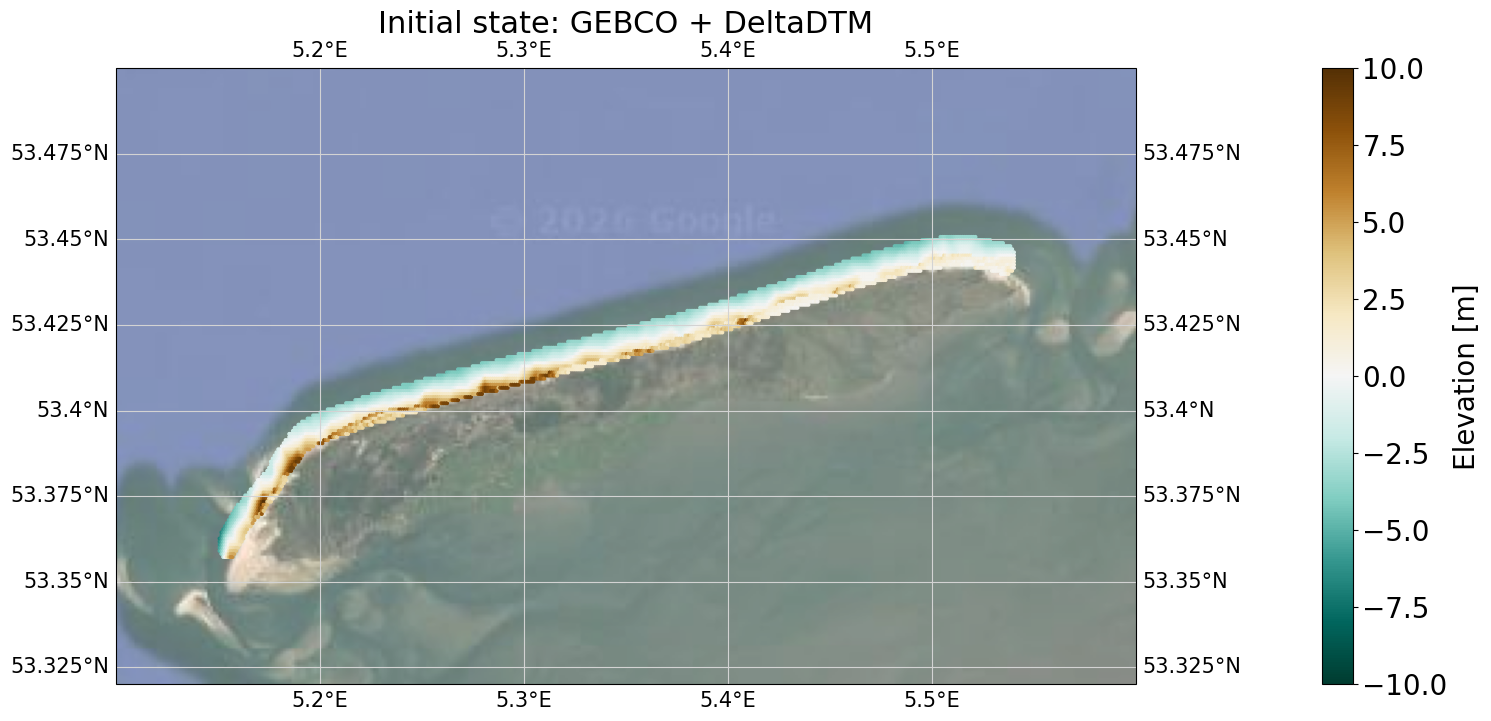

In [15]:
# Plot intial state
init_df = init.to_dataframe()
x = init_df.index.get_level_values('x')
y = init_df.index.get_level_values('y')

projection = ccrs.PlateCarree()
request = cimgt.GoogleTiles(style="satellite")
fig, ax = plt.subplots(figsize=(20,8), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.5], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)
plot = ax.scatter(x, y, c=init_df.band_data, transform=projection, marker='.', s=15,
                  cmap='BrBG_r', vmin=-10, vmax=10)

fig.colorbar(plot, shrink=1, pad=0.12, label='Elevation [m]')
ax.set_title('Initial state: GEBCO + DeltaDTM', fontsize=22);

plt.savefig(f'{path_output}initial_state.png', dpi=300, bbox_inches='tight')

### Jarkus data

In [16]:
jarkus_gdf = CD_jarkus_tools.get_jarkus_data(path_input_general, year_start, year_end, poly_target, init)
jarkus_gdf.to_file(path_output+'jarkus_gdf.geojson')

### Transect polygons

In [17]:
transect_polys = pickle.load(open(path_transect_polys + 'transect_polys.pkl', 'rb'))

## Generate RTS-DTM

In [18]:
# Include trend
fn = 'x_state_s.pkl'
if (not os.path.isfile(path_output + fn)) | new_kalman_run:
    year_ref = 2006
    n_iter = 2

    rs_shoreline = {"dates":c_dates, "shorelines":c_shorelines_corr}
    seg_length = 50 # [m] # segment length used for equalise line string
    seg_length = CD_geometry.dist_meter_to_dist_deg(seg_length) # [deg]
    
    # Initialise state vector
    init_df = init.to_dataframe()
    x = init_df.index.get_level_values('x')
    y = init_df.index.get_level_values('y')    
    x_state = gpd.GeoDataFrame({'init': init_df.band_data.values}, geometry=gpd.points_from_xy(x, y))
    x_state = x_state.set_crs(epsg)

    # Covariance matrix of the initial state
    sigma_xx_init_df = gpd.GeoDataFrame({'sigma': std_init**2}, geometry=x_state.geometry, index=x_state.index)
    sigma_xx_init = diags_array(sigma_xx_init_df.sigma)

    # "Iteration 0"
    x_k = x_state['init'].copy()
    sigma_xx_k = sigma_xx_init

    # Initial trend 
    trends = gpd.GeoDataFrame({'trend_k':np.full(len(init_df.index), 0)}, geometry=x_state.geometry)

    for i in range(0, n_iter):
        x_state, sigma_xx_up, sigma_xx_pred, updated_points, T = CD_kalman.forward_run(
              x_state, init, x_k, sigma_xx_k, year_start, year_end, num_years_per_bin, rs_shoreline,
              seg_length, alt, tidal_corr, epsg, T_is_identity, max_distance, w_id,
              max_noupdate, std_pseudobs, sigma_l, sigma_q, eps_factor, trends['trend_k'].copy(), year_ref)

        # New trend
        trends[f'trend_{i}'] = CD_kalman.compute_trend_in_each_gridpoint(x_state)   
        # Overwrite  trend_k for next iteration
        trends['trend_k'] = trends[f'trend_{i}'].copy()

        # Overwrite x_k so that next iteration starts with residuals and not the full signal
        x_k = x_state.iloc[:,-1].copy() # last entry is x_up_2020 (or whatever end_year is specified)
        sigma_xx_k = sigma_xx_up[list(sigma_xx_up)[-1]] # unordered dict, but should also access end_year

    x_state_s, sigma_xx_s = CD_kalman.backward_run(x_state, sigma_xx_up, sigma_xx_pred, T, eps_factor)

    # Re-add trend
    x_state_readd = x_state.copy()
    x_state_s_readd = x_state_s.copy()

    all_trends = trends.drop(columns=['geometry', 'trend_k']+[col for col in trends.columns if col.startswith('mean_')])
    trend_sum = all_trends.cumsum(axis=1).iloc[:,-2] # second last column, because last trend was not subtracted

    # idx_up, = np.where((updated_points.drop(columns='counter') == 0).any(axis=1))
    year_list = [int(col.split('_')[-1]) for col in x_state.columns if col.startswith('x_up_')]
    for year in year_list:
        deltaYear = year - year_ref
        x_state_readd[f'x_up_{year}'] += trend_sum * deltaYear
        x_state_readd[f'x_pred_{year}'] += trend_sum * deltaYear
        x_state_s_readd[f'x_s_{year}'] += trend_sum * deltaYear

    kf_interp, rts_interp = CD_kalman.interpolate_results(jarkus_gdf, x_state_readd, x_state_s_readd)
    
    # Save kf output
    pickle.dump(x_state, open(f'{path_output}x_state.pkl', 'wb'))
    pickle.dump(sigma_xx_up, open(f'{path_output}sigma_xx_up.pkl', 'wb'))
    pickle.dump(sigma_xx_pred, open(f'{path_output}sigma_xx_pred.pkl', 'wb'))
    pickle.dump(updated_points, open(f'{path_output}updated_points.pkl', 'wb'))
    
    # Save RTS output
    pickle.dump(x_state_s, open(f'{path_output}x_state_s.pkl', 'wb'))
    pickle.dump(sigma_xx_s, open(f'{path_output}sigma_xx_s.pkl', 'wb'))

    # Save interpolated outputs
    pickle.dump(kf_interp, open(f'{path_output}kf_interp.pkl', 'wb'))
    pickle.dump(rts_interp, open(f'{path_output}rts_interp.pkl', 'wb'))
else:
    # Load KF output
    x_state = pickle.load(open(f'{path_output}x_state.pkl', 'rb'))
    sigma_xx_up = pickle.load(open(f'{path_output}sigma_xx_up.pkl', 'rb'))
    sigma_xx_pred = pickle.load(open(f'{path_output}sigma_xx_pred.pkl', 'rb'))
    updated_points = pickle.load(open(f'{path_output}updated_points.pkl', 'rb'))

    # Load RTS output
    x_state_s = pickle.load(open(f'{path_output}x_state_s.pkl', 'rb'))
    sigma_xx_s = pickle.load(open(f'{path_output}sigma_xx_s.pkl', 'rb'))

    # Load interpolated outputs
    kf_interp = pickle.load(open(f'{path_output}kf_interp.pkl', 'rb'))
    rts_interp = pickle.load(open(f'{path_output}rts_interp.pkl', 'rb'))
    
    print(f"Loaded files from {path_output}.")
    

Loaded files from /media/bene/Seagate/PhD-data/98_paper2_kf_dtm/12_13_Ters_DEM/output/.


## Remove height difference between validation and new DTM
from different height reference systems

In [19]:
jarkus_gdf = jarkus_gdf.drop(columns=['2001','2002', '2003', '2012'], errors='ignore')
kf_interp = kf_interp.drop(columns=['2001', '2003'], errors='ignore')
rts_interp = rts_interp.drop(columns=['2001', '2003'], errors='ignore')

In [20]:
diff_kf = kf_interp.drop(columns=['geometry']) - jarkus_gdf.drop(columns=['geometry'])
diff_rts = rts_interp.drop(columns=['geometry']) - jarkus_gdf.drop(columns=['geometry'])
diff_kf_rts = pd.concat([diff_kf, diff_rts], axis=0)

print(f'Mean of all differences (KF-Jarkus and RTS-Jarkus): {round(diff_kf_rts.mean().mean(), 2)}, median: {round(diff_kf_rts.median().median(), 2)}')
bias = diff_kf_rts.median().median()
jarkus_red = jarkus_gdf.copy()
jarkus_red.loc[:, jarkus_red.columns != 'geometry'] += bias

Mean of all differences (KF-Jarkus and RTS-Jarkus): -0.25, median: 0.06


In [21]:
pickle.dump(bias, open(path_output+'bias.pkl', 'wb'))

## Statistics of elevation differences

In [22]:
init_interp = gpd.GeoDataFrame(
        {'geometry':gpd.points_from_xy(jarkus_red.geometry.x, jarkus_red.geometry.y)}).set_crs('4326')
init_interp['init'] = CD_jarkus_tools.interpolate_irregular_grid_onto_JARKUS(x_state, 'init', jarkus_red.geometry.x, jarkus_red.geometry.y)

In [23]:
# Reduce to area inside the shoreline polygon
init_inside_sl = init_interp[init_interp.intersects(poly_sl_corr)]
jarkus_inside_sl = jarkus_red[jarkus_red.intersects(poly_sl_corr)]
kf_inside_sl = kf_interp[kf_interp.intersects(poly_sl_corr)]
rts_inside_sl = rts_interp[rts_interp.intersects(poly_sl_corr)]

### Initial state - Jarkus

In [24]:
jarkus_temp_mean = jarkus_red.drop(columns='geometry').T.mean()

diff_init = init_interp['init'] - jarkus_temp_mean
print(f'Difference initial state - jarkus has {len(diff_init.dropna())} non-NaN values.')

Difference initial state - jarkus has 3206 non-NaN values.


In [25]:
CD_statistics.print_stats(diff_init)

Mean error: -0.3 m
---De-bias with mean---
Mean error: 0.0 m
Mean absolute error: 1.63 m
Root mean square error: 2.61 m
Mean absolute deviation from mean: 1.63 m
Median absolute deviation from median: 1.06 m


In [26]:
year_list = [int(_) for _ in jarkus_inside_sl.drop(columns='geometry').columns]
stats_gdf_init, all_diffs_init = CD_statistics.all_stats_per_year(init_interp['init'], jarkus_red, year_list, reduce_mean=True, static=True)

# Consider only points inside shoreline polygon
stats_gdf_init_in_sl, all_diffs_init_in_sl = CD_statistics.all_stats_per_year(init_inside_sl['init'], jarkus_inside_sl, year_list, reduce_mean=True, static=True)

### RTS/KF-DTM - Jarkus

In [27]:
year_list = [int(_) for _ in rts_interp.drop(columns='geometry').columns]
stats_gdf_rts, all_diffs_rts = CD_statistics.all_stats_per_year(rts_interp, jarkus_red, year_list, reduce_mean=True, static=False)
stats_gdf_kf, all_diffs_kf = CD_statistics.all_stats_per_year(kf_interp, jarkus_red, year_list, reduce_mean=True, static=False)

# Consider only points inside shoreline polygon
stats_gdf_rts_in_sl, all_diffs_rts_in_sl = CD_statistics.all_stats_per_year(rts_inside_sl, jarkus_inside_sl, year_list, reduce_mean=True, static=False)
stats_gdf_kf_in_sl, all_diffs_kf_in_sl = CD_statistics.all_stats_per_year(kf_inside_sl, jarkus_inside_sl, year_list, reduce_mean=True, static=False)

In [28]:
c_init = 'grey'
c_kf = 'brown'
c_rts = 'orange'

In [29]:
def plot_stats(ax, which_stat, title, legend=False, inside_sl=False):
    if inside_sl==False:
        ax.plot(stats_gdf_init.index.astype('int'), stats_gdf_init[which_stat], '.-', c=c_init, label='Initial state - Validation')
        ax.plot(stats_gdf_kf.index.astype('int'), stats_gdf_kf[which_stat], '.-', c=c_kf, label='KF-DTM - Validation')
        ax.plot(stats_gdf_rts.index.astype('int'), stats_gdf_rts[which_stat], '.-', c=c_rts, label='RTS-DTM - Validation')
    
    elif inside_sl==True:
        ax.plot(stats_gdf_init_in_sl.index.astype('int'), stats_gdf_init_in_sl[which_stat], '.-', c=c_init, label='Initial state - Validation')
        ax.plot(stats_gdf_kf_in_sl.index.astype('int'), stats_gdf_kf_in_sl[which_stat], '.-', c=c_kf, label='KF-DTM - Validation')
        ax.plot(stats_gdf_rts_in_sl.index.astype('int'), stats_gdf_rts_in_sl[which_stat], '.-', c=c_rts, label='RTS-DTM - Validation')
    
    ax.grid()
    if legend:
        ax.legend(bbox_to_anchor=(1,1), fontsize=25)
    ax.set_xlabel('Year')
    ax.set_ylabel('[m]')
    ax.set_title(title, fontsize=23, y=1)
    # ax.ticklabel_format(useOffset=False, style='plain')

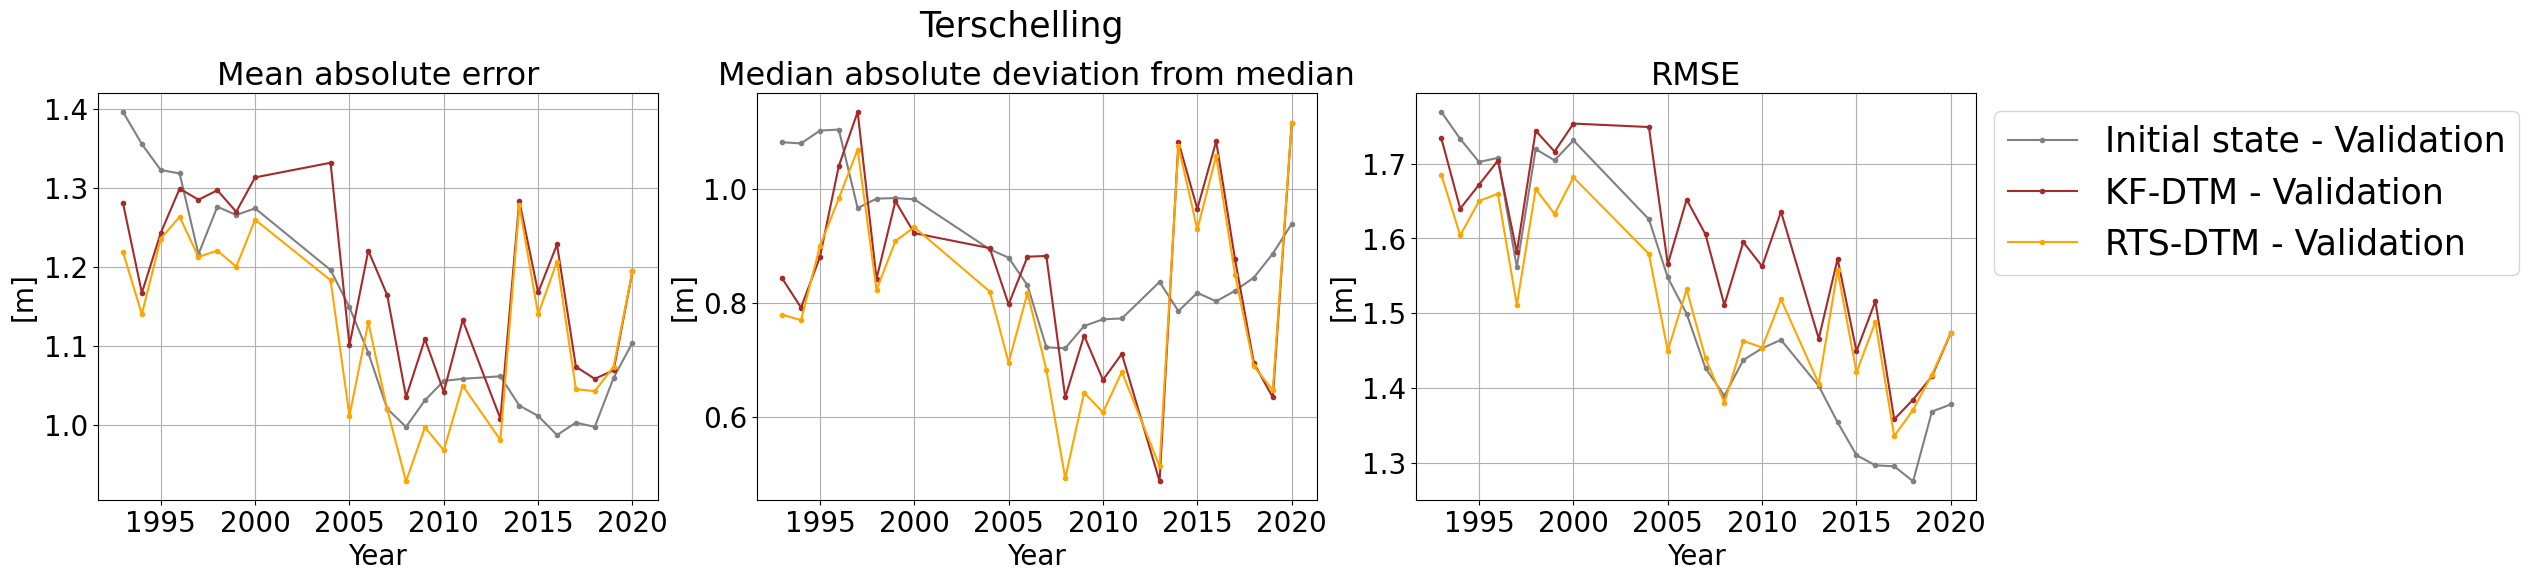

In [30]:
fig, axs = plt.subplots(1, 3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.5)
# fig.suptitle('Statistics of elevation differences averaged over the area covered by shoreline observations', y=1.1, fontsize=25)
fig.suptitle('Terschelling', y=1.1, fontsize=25)
plot_stats(axs[0], which_stat='mae', title='Mean absolute error', inside_sl=True)
plot_stats(axs[1], which_stat='mad_med', title='Median absolute deviation from median', inside_sl=True)
plot_stats(axs[2], which_stat='rmse', title='RMSE', legend=True, inside_sl=True)

plt.savefig(f'{path_output}Ters_vali_stats_elev-diffs_inside_shoreline_poly.png', dpi=300, bbox_inches='tight')

#### Quantify difference init - KF/RTS
positive: init has (on average) larger error  
negative: KF/RTS has larger error  

In [31]:
print(f'Average difference init-KF (inside shoreline area):')
print(f'ME: {round((stats_gdf_init_in_sl.mae - stats_gdf_kf_in_sl.mae).mean(),2)} m')
print(f'MAD: {round((stats_gdf_init_in_sl.mad_med - stats_gdf_kf_in_sl.mad_med).mean(),2)} m')
print(f'RMSE: {round((stats_gdf_init_in_sl.rmse - stats_gdf_kf_in_sl.rmse).mean(),2)} m')

print(f'\nAverage difference init-RTS (inside shoreline area):')
print(f'ME: {round((stats_gdf_init_in_sl.mae - stats_gdf_rts_in_sl.mae).mean(),2)} m')
print(f'MAD: {round((stats_gdf_init_in_sl.mad_med - stats_gdf_rts_in_sl.mad_med).mean(),2)} m')
print(f'RMSE: {round((stats_gdf_init_in_sl.rmse - stats_gdf_rts_in_sl.rmse).mean(),2)} m')

Average difference init-KF (inside shoreline area):
ME: -0.05 m
MAD: 0.03 m
RMSE: -0.08 m

Average difference init-RTS (inside shoreline area):
ME: 0.01 m
MAD: 0.08 m
RMSE: -0.01 m


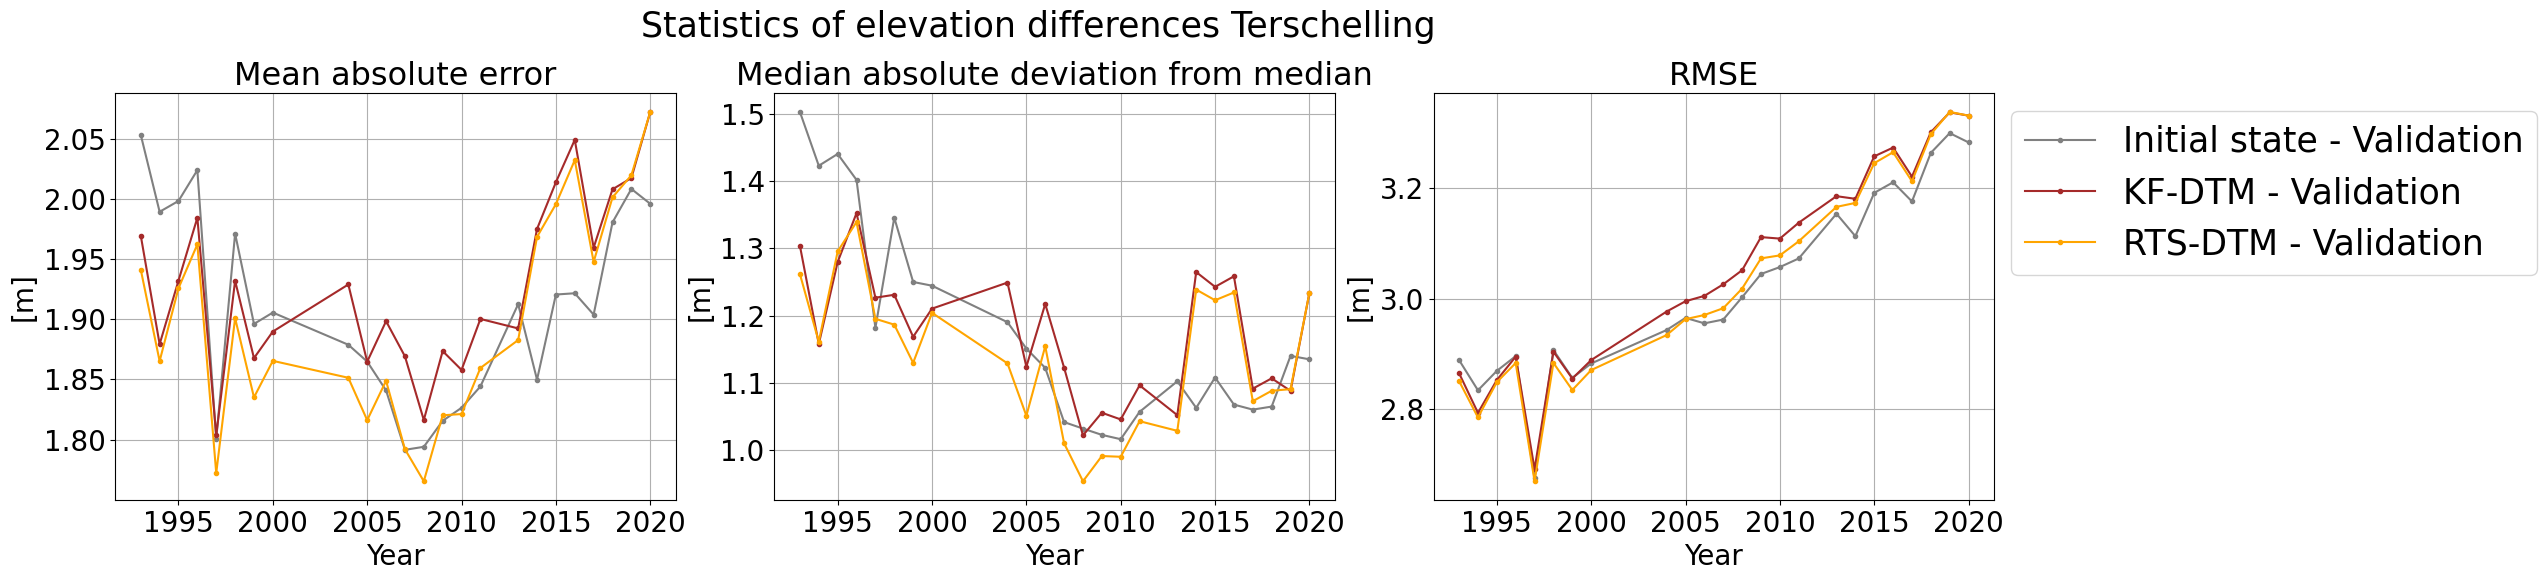

In [32]:
fig, axs = plt.subplots(1, 3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.5)
# fig.suptitle('Statistics of elevation differences averaged over the entire target area', y=1.1, fontsize=25)
fig.suptitle('Statistics of elevation differences Terschelling', y=1.1, fontsize=25)
plot_stats(axs[0], which_stat='mae', title='Mean absolute error')
plot_stats(axs[1], which_stat='mad_med', title='Median absolute deviation from median')
plot_stats(axs[2], which_stat='rmse', title='RMSE', legend=True)

plt.savefig(f'{path_output}Ters_vali_stats_elev-diffs_entire_target_area.png', dpi=300, bbox_inches='tight')

#### Histograms

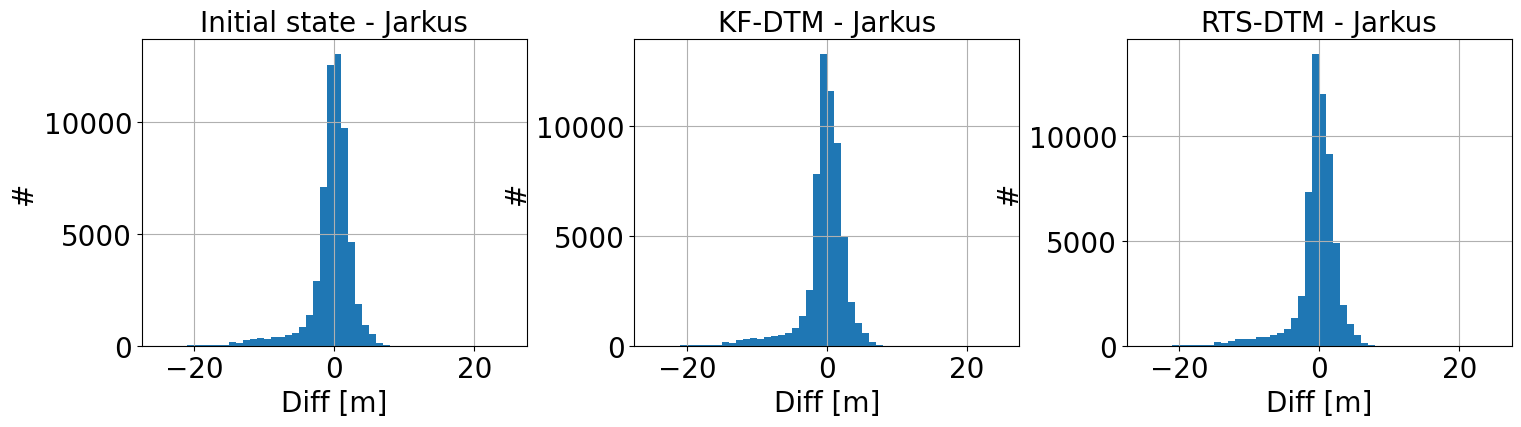

In [33]:
fig, axs = plt.subplots(1,3, figsize=(15,4))
fig.tight_layout()
CD_visualisation.plot_histogram(axs[0], all_diffs_init, 'Initial state - Jarkus')
CD_visualisation.plot_histogram(axs[1], all_diffs_kf, 'KF-DTM - Jarkus')
CD_visualisation.plot_histogram(axs[2], all_diffs_rts, 'RTS-DTM - Jarkus')

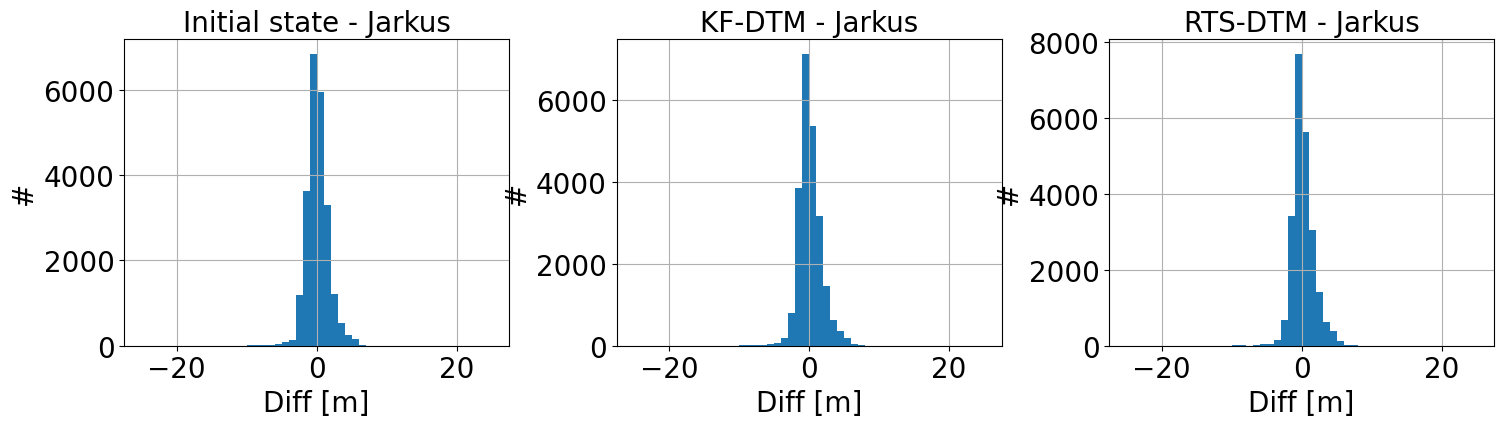

In [34]:
fig, axs = plt.subplots(1,3, figsize=(15,4))
fig.tight_layout()
CD_visualisation.plot_histogram(axs[0], all_diffs_init_in_sl, 'Initial state - Jarkus')
CD_visualisation.plot_histogram(axs[1], all_diffs_kf_in_sl, 'KF-DTM - Jarkus')
CD_visualisation.plot_histogram(axs[2], all_diffs_rts_in_sl, 'RTS-DTM - Jarkus')

#### Map

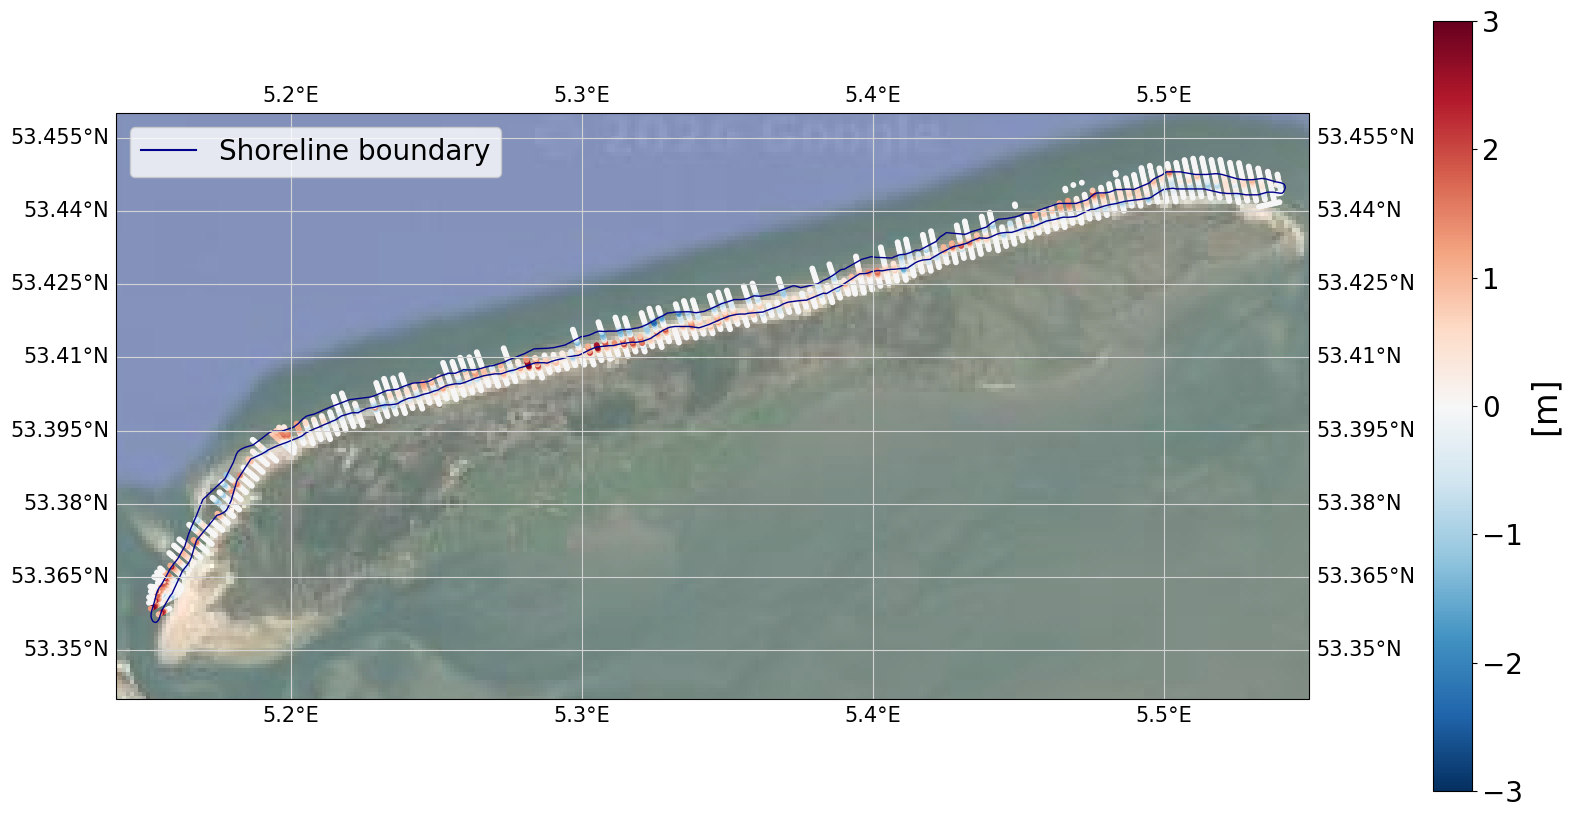

In [35]:
year = '1993'
diff_init = init_interp['init'] - jarkus_red[year]
diff_rts = rts_interp[year] - jarkus_red[year]
diff_rts_init = np.abs(diff_init) - np.abs(diff_rts)

fig, ax = plt.subplots(figsize=(20,10), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.14, 5.55, 53.34, 53.46], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
request = cimgt.GoogleTiles(style="satellite")
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

x = jarkus_red.geometry.x
y = jarkus_red.geometry.y
plot = ax.scatter(x, y, marker='o', s=10, c=diff_rts_init, transform=ccrs.PlateCarree(),
                  cmap='RdBu_r', vmin=-3, vmax=3)

ax.add_geometries(poly_sl_corr, crs=projection, facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)
proxy_poly_sl_corr = Line2D([0], [0], color='darkblue', label='Shoreline boundary')
ax.legend(handles=[proxy_poly_sl_corr])

plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)
# ax.set_title(f'Difference of errors initial state - RTS-DTM {year} for Terschelling', fontsize=24);

plt.savefig(f'{path_output}Ters_map_diff_errors_init-RTS_{year}.png', dpi=300, bbox_inches='tight')

## Time series of volume changes

In [117]:
def plot_volume_changes(ax, vol_jarkus, vol_kf, vol_rts, title_area, legend=False):
    ax.plot(vol_jarkus.index, vol_jarkus, '.-', c=c_init, label='Validation')
    ax.plot(vol_kf.index, vol_kf, '.-', c=c_kf, label='KF-DTM')
    ax.plot(vol_rts.index, vol_rts, '.-', c=c_rts, label='RTS-DTM')
    ax.set_ylabel(r'[$m^3$]')
    ax.set_xlabel('Year')
    ax.set_title(f'{title_area}', fontsize=22)
    ax.grid()
    if legend:
        ax.legend(bbox_to_anchor=(1,1), fontsize=22)    

In [ ]:
volumes_jarkus = pd.DataFrame(index=[int(_) for _ in jarkus_red.drop(columns='geometry').columns])
volumes_kf = volumes_jarkus.copy()
volumes_rts = volumes_jarkus.copy()

for idx_transect in transect_polys.keys():
    volumes_jarkus[idx_transect] = CD_geometry.compute_volume_changes(jarkus_red, transect_polys[idx_transect], col_name='', epsg_out=epsg_local)
    volumes_kf[idx_transect] = CD_geometry.compute_volume_changes(kf_interp, transect_polys[idx_transect], col_name='', epsg_out=epsg_local)
    volumes_rts[idx_transect] = CD_geometry.compute_volume_changes(rts_interp, transect_polys[idx_transect], col_name='', epsg_out=epsg_local)

Average volume first and then compute statistics, because I'm more interested in the model performance over the entire area and not the errors of every single transect. Right?

In [92]:
# Plot elevations inside the transect polygons
%matplotlib qt5
def plot_elevations(data):
    fig, ax = plt.subplots(figsize=(20,10), subplot_kw=dict(projection=request.crs))
    ax.set_extent([5.14, 5.55, 53.34, 53.46], crs=ccrs.PlateCarree())
    ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
    x = jarkus_red.geometry.x
    y = jarkus_red.geometry.y
    plot = ax.scatter(x, y, marker='o', s=10, c=data.drop(columns=['geometry']).mean(axis=1), transform=ccrs.PlateCarree(),
                     cmap='BrBG_r', vmin=-10, vmax=10)
    plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)

    # for key in transect_polys.keys():
    #     ax.add_geometries(transect_polys[key], crs=projection, facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)

plot_elevations(jarkus_red)
plot_elevations(kf_interp)
plot_elevations(rts_interp)

In [ ]:
# West Terschelling erosive section
idx_west = [25, 57]
# Middle accretive section
idx_middle = [58, 111]
# East Terschelling erosive section
idx_east = [112, 144]

volumes_jarkus_west = volumes_jarkus.iloc[:, idx_west[0]:idx_west[1]]
volumes_jarkus_middle = volumes_jarkus.iloc[:, idx_middle[0]:idx_middle[1]]
volumes_jarkus_east = volumes_jarkus.iloc[:, idx_east[0]:idx_east[1]]

volumes_kf_west = volumes_kf.iloc[:, idx_west[0]:idx_west[1]]
volumes_kf_middle = volumes_kf.iloc[:, idx_middle[0]:idx_middle[1]]
volumes_kf_east = volumes_kf.iloc[:, idx_east[0]:idx_east[1]]

volumes_rts_west = volumes_rts.iloc[:, idx_west[0]:idx_west[1]]
volumes_rts_middle = volumes_rts.iloc[:, idx_middle[0]:idx_middle[1]]
volumes_rts_east = volumes_rts.iloc[:, idx_east[0]:idx_east[1]]

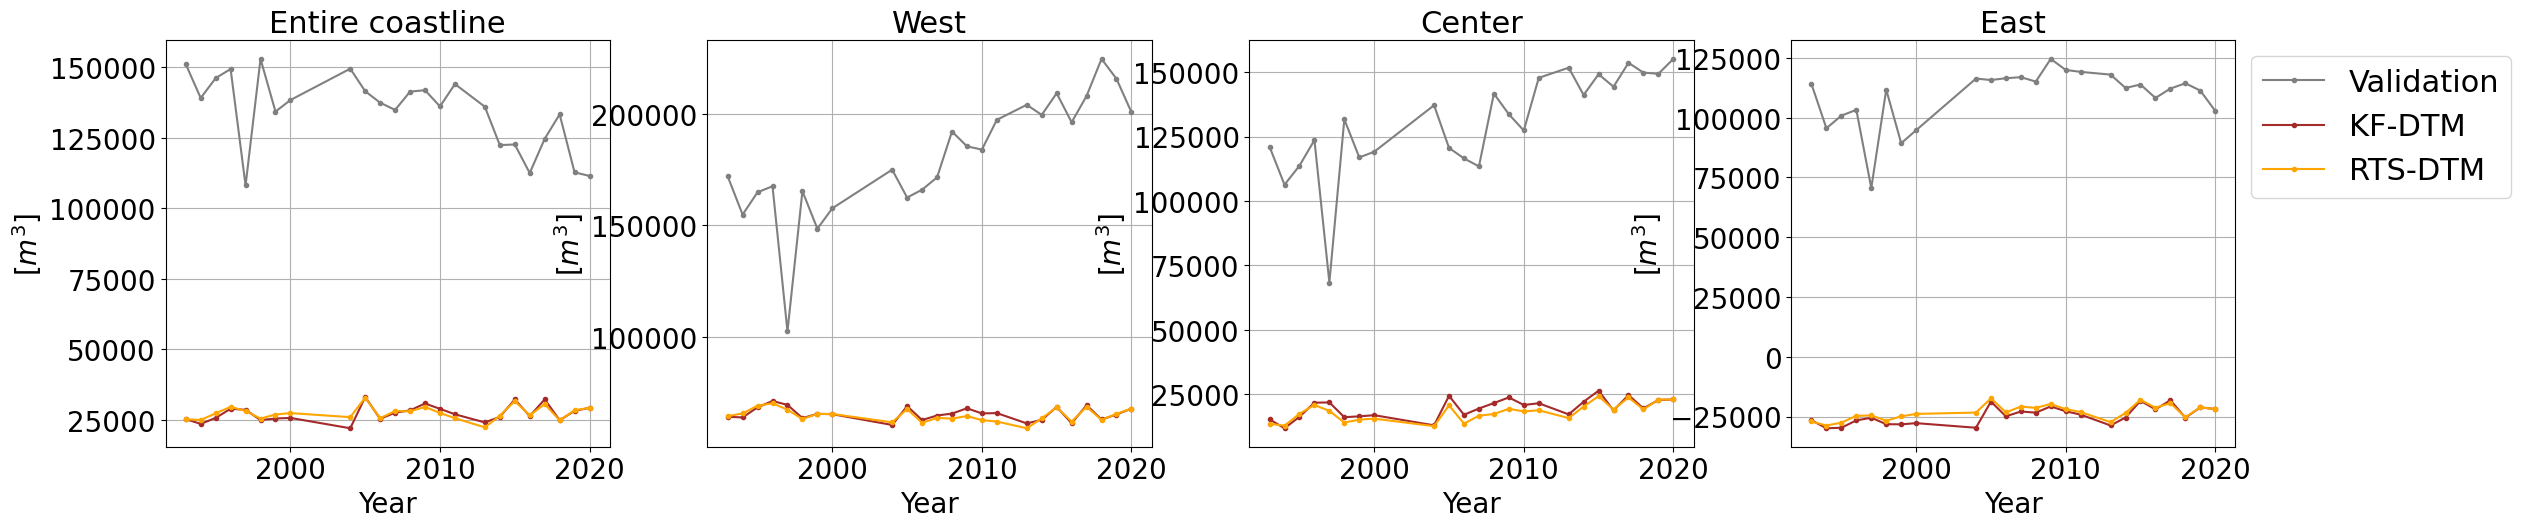

In [86]:
%matplotlib inline
fig, axs = plt.subplots(1,4, figsize=(22,5))
fig.tight_layout()
fig.subplots_adjust(wspace=.22)
# fig.suptitle('Volume changes Terschelling', fontsize=25, y=1.1)

plot_volume_changes(axs[0], volumes_jarkus.mean(axis=1), volumes_kf.mean(axis=1), volumes_rts.mean(axis=1), 'Entire coastline')
plot_volume_changes(axs[1], volumes_jarkus_west.mean(axis=1), volumes_kf_west.mean(axis=1), volumes_rts_west.mean(axis=1), 'West')
plot_volume_changes(axs[2], volumes_jarkus_middle.mean(axis=1), volumes_kf_middle.mean(axis=1), volumes_rts_middle.mean(axis=1), 'Center')
plot_volume_changes(axs[3], volumes_jarkus_east.mean(axis=1), volumes_kf_east.mean(axis=1), volumes_rts_east.mean(axis=1), 'East', legend=True)

# plt.savefig(f'{path_output}Ters_validation_volume_changes.png', dpi=300, bbox_inches='tight')

### Only area covered by shoreline observations

In [93]:
volumes_jarkus_inside_sl = pd.DataFrame(index=[int(_) for _ in jarkus_red.drop(columns='geometry').columns])
volumes_kf_inside_sl = volumes_jarkus.copy()
volumes_rts_inside_sl = volumes_jarkus.copy()

for idx_transect in transect_polys.keys():
    volumes_jarkus_inside_sl[idx_transect] = CD_geometry.compute_volume_changes(jarkus_inside_sl, transect_polys[idx_transect], col_name='', epsg_out=epsg_local)
    volumes_kf_inside_sl[idx_transect] = CD_geometry.compute_volume_changes(kf_inside_sl, transect_polys[idx_transect], col_name='', epsg_out=epsg_local)
    volumes_rts_inside_sl[idx_transect] = CD_geometry.compute_volume_changes(rts_inside_sl, transect_polys[idx_transect], col_name='', epsg_out=epsg_local)

In [94]:
# West Terschelling erosive section
idx_west = [25, 57]
# Middle accretive section
idx_middle = [58, 111]
# East Terschelling erosive section
idx_east = [112, 144]

volumes_jarkus_west_inside_sl = volumes_jarkus_inside_sl.iloc[:, idx_west[0]:idx_west[1]]
volumes_jarkus_middle_inside_sl = volumes_jarkus_inside_sl.iloc[:, idx_middle[0]:idx_middle[1]]
volumes_jarkus_east_inside_sl = volumes_jarkus_inside_sl.iloc[:, idx_east[0]:idx_east[1]]

volumes_kf_west_inside_sl = volumes_kf_inside_sl.iloc[:, idx_west[0]:idx_west[1]]
volumes_kf_middle_inside_sl = volumes_kf_inside_sl.iloc[:, idx_middle[0]:idx_middle[1]]
volumes_kf_east_inside_sl = volumes_kf_inside_sl.iloc[:, idx_east[0]:idx_east[1]]

volumes_rts_west_inside_sl = volumes_rts_inside_sl.iloc[:, idx_west[0]:idx_west[1]]
volumes_rts_middle_inside_sl = volumes_rts_inside_sl.iloc[:, idx_middle[0]:idx_middle[1]]
volumes_rts_east_inside_sl = volumes_rts_inside_sl.iloc[:, idx_east[0]:idx_east[1]]

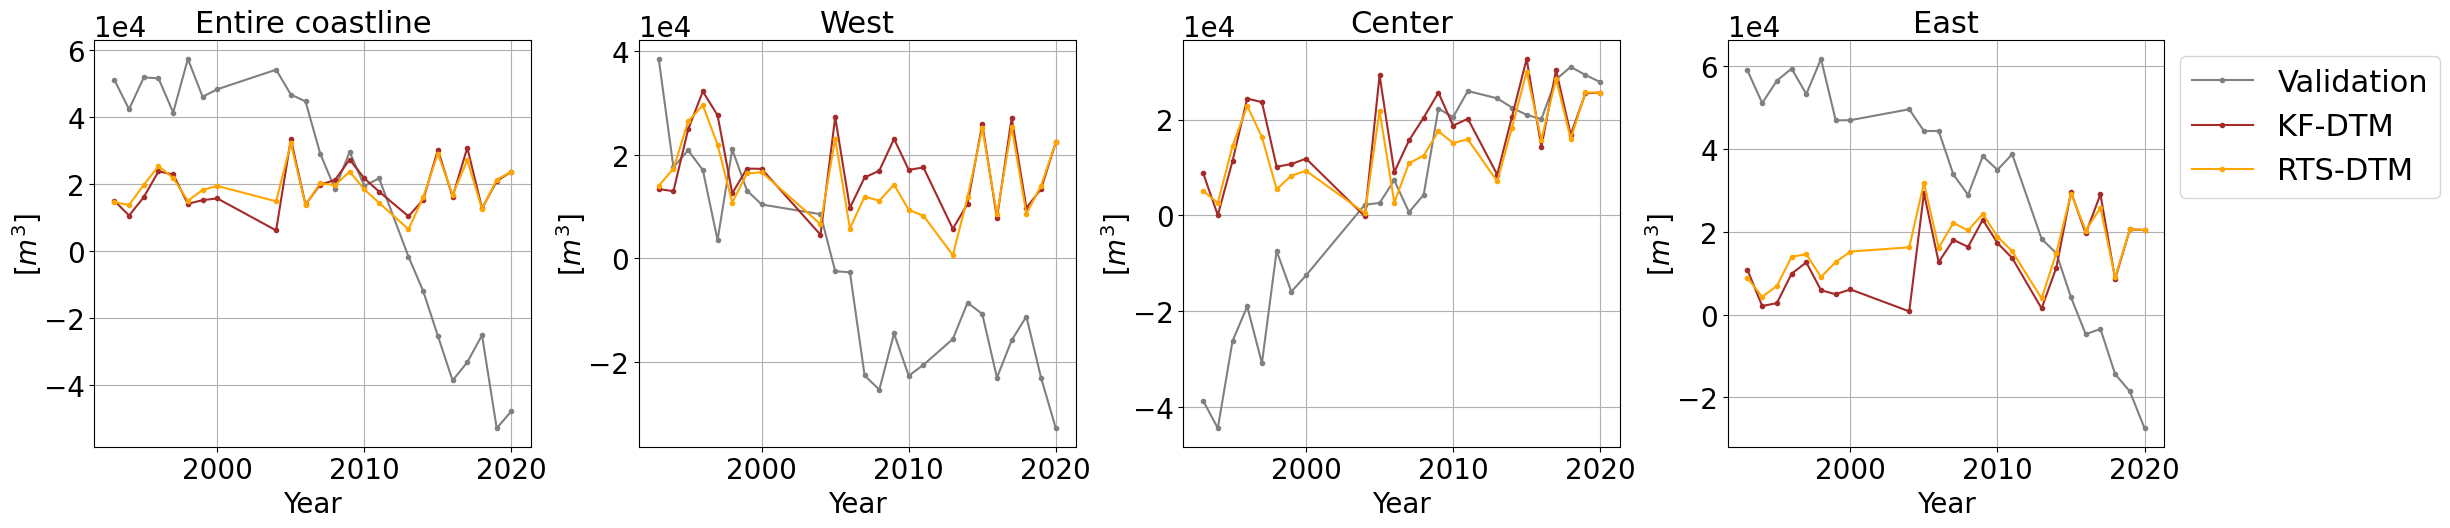

In [121]:
%matplotlib inline
fig, axs = plt.subplots(1,4, figsize=(22,5))
fig.tight_layout()
# fig.subplots_adjust(wspace=.22)
# fig.suptitle('Volume changes Terschelling', fontsize=25, y=1.1)

plot_volume_changes(axs[0], volumes_jarkus_inside_sl.mean(axis=1), volumes_kf_inside_sl.mean(axis=1), volumes_rts_inside_sl.mean(axis=1), 'Entire coastline')
plot_volume_changes(axs[1], volumes_jarkus_west_inside_sl.mean(axis=1), volumes_kf_west_inside_sl.mean(axis=1), volumes_rts_west_inside_sl.mean(axis=1), 'West')
plot_volume_changes(axs[2], volumes_jarkus_middle_inside_sl.mean(axis=1), volumes_kf_middle_inside_sl.mean(axis=1), volumes_rts_middle_inside_sl.mean(axis=1), 'Center')
plot_volume_changes(axs[3], volumes_jarkus_east_inside_sl.mean(axis=1), volumes_kf_east_inside_sl.mean(axis=1), volumes_rts_east_inside_sl.mean(axis=1), 'East', legend=True)

for ax in axs:
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.savefig(f'{path_output}Ters_validation_volume_changes.png', dpi=300, bbox_inches='tight')

### Statistics compared to JARKUS

In [152]:
vol_rmse = {}
vol_corr = {}
vol_pvalues = {}

trends = {}
Cxxs = {}
vs = {}

In [153]:
vol_rmse['all'] = CD_statistics.RMSE_timeseries(volumes_rts_inside_sl.mean(axis=1), volumes_jarkus_inside_sl.mean(axis=1))
vol_rmse['west'] = CD_statistics.RMSE_timeseries(volumes_rts_west_inside_sl.mean(axis=1), volumes_jarkus_west_inside_sl.mean(axis=1))
vol_rmse['center'] = CD_statistics.RMSE_timeseries(volumes_rts_middle_inside_sl.mean(axis=1), volumes_jarkus_middle_inside_sl.mean(axis=1))
vol_rmse['east'] = CD_statistics.RMSE_timeseries(volumes_rts_east_inside_sl.mean(axis=1), volumes_jarkus_east_inside_sl.mean(axis=1))

In [155]:
vol_corr['all'], vol_pvalues['all'] = stats.pearsonr(volumes_rts_inside_sl.mean(axis=1), volumes_jarkus_inside_sl.mean(axis=1))
vol_corr['west'], vol_pvalues['west'] = stats.pearsonr(volumes_rts_west_inside_sl.mean(axis=1), volumes_jarkus_west_inside_sl.mean(axis=1))
vol_corr['center'], vol_pvalues['center'] = stats.pearsonr(volumes_rts_middle_inside_sl.mean(axis=1), volumes_jarkus_middle_inside_sl.mean(axis=1))
vol_corr['east'], vol_pvalues['east'] = stats.pearsonr(volumes_rts_east_inside_sl.mean(axis=1), volumes_jarkus_east_inside_sl.mean(axis=1))

In [158]:
years = volumes_jarkus_inside_sl.index.values

In [159]:
trends['jarkus_all'], _, _ = CD_statistics.compute_trend_with_error(years, volumes_jarkus_inside_sl.mean(axis=1))
trends['jarkus_west'], _, _ = CD_statistics.compute_trend_with_error(years, volumes_jarkus_west_inside_sl.mean(axis=1))
trends['jarkus_center'], _, _ = CD_statistics.compute_trend_with_error(years, volumes_jarkus_middle_inside_sl.mean(axis=1))
trends['jarkus_east'], _, _ = CD_statistics.compute_trend_with_error(years, volumes_jarkus_east_inside_sl.mean(axis=1))

In [160]:
trends['kf_all'], _, _ = CD_statistics.compute_trend_with_error(years, volumes_kf_inside_sl.mean(axis=1))
trends['kf_west'], _, _ = CD_statistics.compute_trend_with_error(years, volumes_kf_west_inside_sl.mean(axis=1))
trends['kf_center'], _, _ = CD_statistics.compute_trend_with_error(years, volumes_kf_middle_inside_sl.mean(axis=1))
trends['kf_east'], _, _ = CD_statistics.compute_trend_with_error(years, volumes_kf_east_inside_sl.mean(axis=1))

In [161]:
trends['rts_all'], _, _ = CD_statistics.compute_trend_with_error(years, volumes_rts_inside_sl.mean(axis=1))
trends['rts_west'], _, _ = CD_statistics.compute_trend_with_error(years, volumes_rts_west_inside_sl.mean(axis=1))
trends['rts_center'], _, _ = CD_statistics.compute_trend_with_error(years, volumes_rts_middle_inside_sl.mean(axis=1))
trends['rts_east'], _, _ = CD_statistics.compute_trend_with_error(years, volumes_rts_east_inside_sl.mean(axis=1))

In [162]:
trends

{'jarkus_all': -3820.4261,
 'jarkus_west': -1894.7135,
 'jarkus_center': 2564.4395,
 'jarkus_east': -2877.5054,
 'kf_all': 210.3039,
 'kf_west': -154.5789,
 'kf_center': 518.9743,
 'kf_east': 559.0793,
 'rts_all': 61.9816,
 'rts_west': -212.5898,
 'rts_center': 546.9922,
 'rts_east': 396.4987}

In [163]:
trend_diff = {}
trend_diff_perc = {}
for area in ['all', 'west', 'center', 'east']:
    trend_diff[area] = trends[f'rts_{area}'] - trends[f'jarkus_{area}']
    
    if np.sign(trends[f'rts_{area}']) == np.sign(trends[f'jarkus_{area}']):
        # both trends are neg/pos (median, hope that sign is same for each parameter combination): perc as quotient of absolute trend diff
        trend_diff_perc[area] = (np.abs(trend_diff[area]) / np.abs(trends[f'jarkus_{area}'])) * 100
    else:
        # trends have different signs: perc should be negative
        trend_diff_perc[area] = (trend_diff[area] / trends[f'jarkus_{area}']) * 100

In [164]:
trend_diff_perc

{'all': -101.62237400692034,
 'west': 88.77984455169607,
 'center': 78.67010705458249,
 'east': -113.77925129176126}

In [167]:
print('RMSE relative to total mean volume:')
for key, value in vol_rmse.items():
    total_mean_vol = np.nanmean(volumes_jarkus_inside_sl.mean(axis=1))
    perc = (np.abs(value) / np.abs(total_mean_vol)) * 100
    print(key, round(perc,1))

RMSE relative to total mean volume:
all 213.0
west 103.7
center 115.5
east 171.1


In [166]:
print('Correlation:')
for key, value in vol_corr.items():
    print(key, round(value,2))
    
print('\np-values:')
for key, value in vol_pvalues.items():
    print(key, round(value,2))

Correlation:
all -0.12
west 0.25
center 0.5
east -0.34

p-values:
all 0.59
west 0.24
center 0.01
east 0.1


### Trend histogram for all study areas

In [169]:
path_duck = path_to_data_folder + '22_23_Duck_DEM/output/'
trends_duck = pickle.load(open(path_duck + 'Duck_validation_trends.pkl', 'rb'))

path_narra = path_to_data_folder + '32_33_Narrabeen_DEM/output/'
trends_narra = pickle.load(open(path_narra + 'Narra_validation_trends.pkl', 'rb'))

In [170]:
def plot_trend_bars(ax, x_start, y_text, trend_kf, trend_rts, trend_jarkus, color):
    fs = 15
    textcolor = 'dimgrey'
    
    ax.bar(x_start, trend_kf, color=color)
    ax.bar(x_start+1, trend_rts, color=color)
    ax.bar(x_start+2, trend_jarkus, color=color)    
    
    ax.text(x_start-.5, y_text, 'KF-DTM', rotation=90, fontsize=fs, c=textcolor)
    ax.text(x_start+.5, y_text, 'RTS-DTM', rotation=90, fontsize=fs, c=textcolor)
    ax.text(x_start+1.5, y_text, 'Validation', rotation=90, fontsize=fs, c=textcolor)

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(13,4))
fig.tight_layout()
plot_trend_bars(axs[0], 0, 50000, trends['kf_all'], trends['rts_all'], trends['jarkus_all'], 'indigo')
plot_trend_bars(axs[0], 4, 10000, trends['kf_west'], trends['rts_west'], trends['jarkus_west'], 'darkblue')
plot_trend_bars(axs[0], 8, -150000, trends['kf_center'], trends['rts_center'], trends['jarkus_center'], 'darkgreen')
plot_trend_bars(axs[0], 12, 20000, trends['kf_east'], trends['rts_east'], trends['jarkus_east'], 'orange')
plot_trend_bars(axs[0], 16, 20000, trends_duck['kf'], trends_duck['rts'], trends_duck['vali'], 'darkred')

axs[0].set_xticks([1,5,9,13,17], ['Entire \ncoastline', 'West', 'Centre', 'East', 'Duck'], rotation=90)
axs[0].set_ylabel(r'$m^3$/year')
# axs[0].set_title('a) Volume change trends Terschelling & Duck')
axs[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axs[0].grid()

plot_trend_bars(axs[1], 0, -350, trends_narra['kf_PF1'], trends_narra['rts_PF1'], trends_narra['vali_PF1'], 'lightblue')
plot_trend_bars(axs[1], 4, -350, trends_narra['kf_PF2'], trends_narra['rts_PF2'], trends_narra['vali_PF2'], 'pink')
plot_trend_bars(axs[1], 8, -350, trends_narra['kf_PF4'], trends_narra['rts_PF4'], trends_narra['vali_PF4'], 'lightblue')
plot_trend_bars(axs[1], 12, -350, trends_narra['kf_PF6'], trends_narra['rts_PF6'], trends_narra['vali_PF6'], 'pink')
plot_trend_bars(axs[1], 16, -350, trends_narra['kf_PF8'], trends_narra['rts_PF8'], trends_narra['vali_PF8'], 'lightblue')

axs[1].set_xticks([1,5,9,13,17], ['Profile 1', 'Profile 2', 'Profile 4', 'Profile 6', 'Profile 8'], rotation=90)
axs[1].set_ylabel(r'$m^3$/year', labelpad=-30)
# axs[1].set_title('b) Volume change trends Narrabeen', pad=25)
axs[1].set_ylim([-600, 600])
axs[1].grid()

plt.savefig(f'{path_output}validation_trend_barplot.png', dpi=300, bbox_inches='tight')

### Jarkus shoreline change trends map

## Time series of elevation changes

### Statistics compared to JARKUS

In [ ]:
elev_stats = pd.DataFrame(index=jarkus_red.index)

for jarkus_point in jarkus_red.index:
    rts_ts = rts_interp.drop(columns='geometry').iloc[jarkus_point]
    idx, = np.where(np.isin(jarkus_red.columns, rts_ts.index)) # where jarkus years and rts years overlap
    jarkus_ts = jarkus_red.loc[jarkus_point].iloc[idx].astype(float)
    
    not_nan = np.logical_or(np.isnan(rts_ts), jarkus_ts.isna())
    # if number of nan values more than 50 % of the total number of values
    if not_nan.sum() > len(rts_ts)/2: # at least 50 % overlapping non-nan values
        continue
        
    # RMSE
    elev_stats.loc[jarkus_point, 'rmse'] = CD_statistics.RMSE_timeseries(rts_ts, jarkus_ts)
    
    # # Correlation
    elev_stats.loc[jarkus_point, 'corr'], elev_stats.loc[jarkus_point, 'pvalue'] = stats.pearsonr(jarkus_ts[~not_nan], rts_ts[~not_nan])
    
    # Trend in m/year, Cxx: cov.matrix, v: diff between observations and model
    elev_trend_rts, _, _ = CD_statistics.compute_trend_with_error(rts_ts.index.values.astype(int), rts_ts.values)
    elev_trend_jarkus, _, _ = CD_statistics.compute_trend_with_error(jarkus_ts.index.values.astype(int), jarkus_ts.values)
    elev_stats.loc[jarkus_point, 'trend_diff'] = elev_trend_rts - elev_trend_jarkus


In [ ]:
CD_visualisation.plot_map(4326, jarkus_red.geometry.x, jarkus_red.geometry.y, elev_stats['rmse'], vminmax=[0,2], cmap='Blues',
                          title='Elevation time series, RMSE', label='[m]')

In [ ]:
CD_visualisation.plot_map(4326, jarkus_red.geometry.x, jarkus_red.geometry.y, elev_stats['corr'], vminmax=[-1,1], cmap='RdBu',
                          title='Elevation time series, Correlation', label='[m]')

In [ ]:
CD_visualisation.plot_map(4326, jarkus_red.geometry.x, jarkus_red.geometry.y, elev_stats['trend_diff'], vminmax=[-.3,.3], cmap='RdBu',
                          title='Elevation time series, Trend differences', label='[m/year]')

## Animation

In [ ]:
poly_sl_corr = CD_geometry.get_area_covered_by_shorelines(c_shorelines_corr, alpha=100, buffer_size=0)

#### KF

In [ ]:
if animation:
    col_idx = ['x_' in _ for _ in x_state.columns]
    col_list_kf = x_state.loc[:,col_idx].columns.to_list()
    col_list_kf[1] = 'init'
    del col_list_kf[0]
    
    x_state_in_sl_poly = x_state[x_state.intersects(poly_sl_corr)]
    
    x = x_state_in_sl_poly.geometry.x
    y = x_state_in_sl_poly.geometry.y
    anim = CD_visualisation.movie(x_state_in_sl_poly, x, y,
            col_list_kf, first_col='init', extent=[5.1, 5.6, 53.32, 53.5], zoom=10,
            pixelsize=1, savepath=path_output, fn='KF.gif')

#### RTS

In [ ]:
if animation:
    col_idx = ['x_s' in _ for _ in x_state_s.columns]
    col_list_s = x_state_s.loc[:,col_idx].columns.to_list()
    
    x_state_s_in_sl_poly = x_state_s[x_state_s.intersects(poly_sl_corr)]
    x = x_state_s_in_sl_poly.geometry.x
    y = x_state_s_in_sl_poly.geometry.y
    
    anim_RTS = CD_visualisation.movie(x_state_s_in_sl_poly, x, y,
                col_list_s, first_col='x_s_2020', extent=[5.1, 5.6, 53.32, 53.5], zoom=10,
                pixelsize=1, savepath=path_output, fn='RTS.gif')

#### Single year result map

In [ ]:
mask_max_elev = 2.5

# %matplotlib qt5
%matplotlib inline
projection = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,10), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.49], crs=projection)
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
request = cimgt.GoogleTiles(style="satellite")
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

idx, = np.where(abs(x_state_s['x_s_1993']) < mask_max_elev)
x = x_state.geometry.x[idx]
y = x_state.geometry.y[idx]
data = x_state_s['x_s_1993'][idx]

# x = x_state.geometry.x
# y = x_state.geometry.y
# data = x_state_s['x_s_1993']

plot = ax.scatter(x, y, marker='o', s=.5, c = data,
                  cmap='BrBG_r', transform=ccrs.PlateCarree(), vmin=-2, vmax=2, )

ax.add_geometries(poly_sl_corr, crs=projection, facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)

plt.colorbar(plot, shrink=.7, pad=.08).set_label(label='[m]',size=24)
proxy_poly_sl_corr = Line2D([0], [0], color='darkblue', label='Shoreline boundary')
ax.legend(handles=[proxy_poly_sl_corr])
ax.set_title(f'RTS DTM 1993 (only values < {mask_max_elev})')

plt.savefig(f'{path_output}RTS_DTM_1993.png', dpi=300, bbox_inches='tight')

In [ ]:
diff = x_state_s['x_s_1993'] - x_state['x_up_1993']

projection = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,10), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.49], crs=projection)
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
request = cimgt.GoogleTiles(style="satellite")
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

plot = ax.scatter(x_state.geometry.x, x_state.geometry.y, marker='o', s=.5, c=diff,
                  cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin=-.5, vmax=.5, )

ax.add_geometries(poly_sl_corr, crs=projection, facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)

plt.colorbar(plot, shrink=.7, pad=.08).set_label(label='[m]',size=24)
proxy_poly_sl_corr = Line2D([0], [0], color='darkblue', label='Shoreline boundary')
ax.legend(handles=[proxy_poly_sl_corr])
ax.set_title('Difference KF - RTS DTM 1993');

plt.savefig(f'{path_output}diff_kf-rts_1993.png', dpi=300, bbox_inches='tight')